# Telco Customer Churn

## Loading

In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [343]:
df = pd.read_csv("data/Telco_customer_churn.csv")

print(df.shape)
print(df.info())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [344]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

TotalCharges column has data type object and when trying to convert into float with astype(float), it raised an error which says there is string value consisting of empty spaces.

In [345]:
print(df["TotalCharges"].dtype)
df[df['TotalCharges'] == ' ']

object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


To_numeric converts object dtype to float and any rows that raise error become Null values.

In [346]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].dtype

dtype('float64')

In [347]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Customers with empty TotalCharges have 0 tenure which means they are new customers who haven't churned.

In [348]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Dropping these 11 rows out of 7042 is a good idea since it is too small to matter and these customers have just signed up and have no experience with the service so they don't add meaningful information to model.

In [349]:
df.dropna(subset=["TotalCharges"], inplace=True)
print(df.shape)

(7032, 21)


Data is moderately imbalanced (26.5% churn rate) which is understandable in Churn dataset.

In [350]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [351]:
df.drop(columns=['customerID'], inplace=True)

## Exploratory Data Analysis

In [352]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

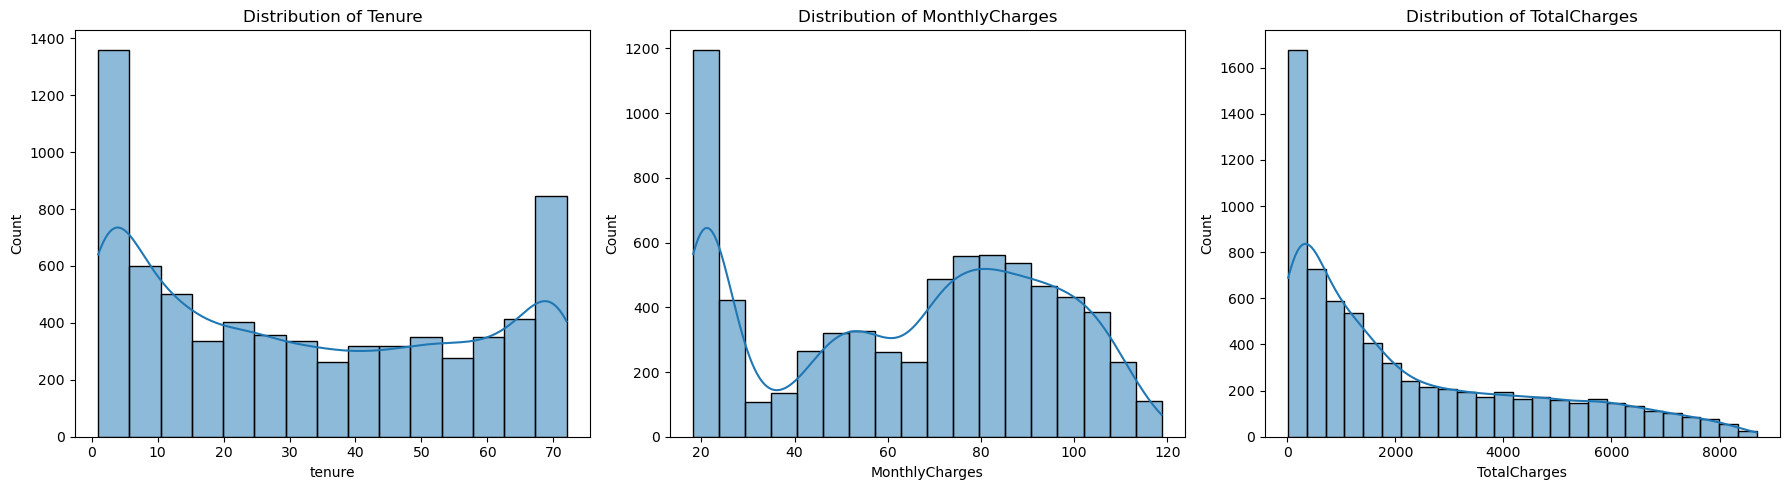

In [353]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["tenure"], ax=axes[0], kde=True)
axes[0].set_title('Distribution of Tenure')

sns.histplot(df["MonthlyCharges"], ax=axes[1], kde=True)
axes[1].set_title('Distribution of MonthlyCharges')

sns.histplot(df["TotalCharges"], ax=axes[2], kde=True)
axes[2].set_title('Distribution of TotalCharges')

plt.tight_layout()
plt.show()

In [354]:
print(f"Tenure skew: {df["tenure"].skew():.3f}")
print(f"MonthlyCharges skew: {df["MonthlyCharges"].skew():.3f}")
print(f"TotalCharges skew: {df["TotalCharges"].skew():.3f}")

Tenure skew: 0.238
MonthlyCharges skew: -0.222
TotalCharges skew: 0.962


From Tenure distribution, it is understandable that two types of customers exist:
1. People who leave very eraly (big spike at 0-10)
2. People who are loyal long-term (spke at 60-70)
   
Obviously, people who churn have less tenure.

In [355]:
df.groupby("Churn")["tenure"].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

Churned customers pay more on average and higher prices cause churn.

In [356]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

Churned customers have lower total charges becuase they leave earlier and that makes up for less total spend.

In [357]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
0    2555.344141
1    1531.796094
Name: TotalCharges, dtype: float64

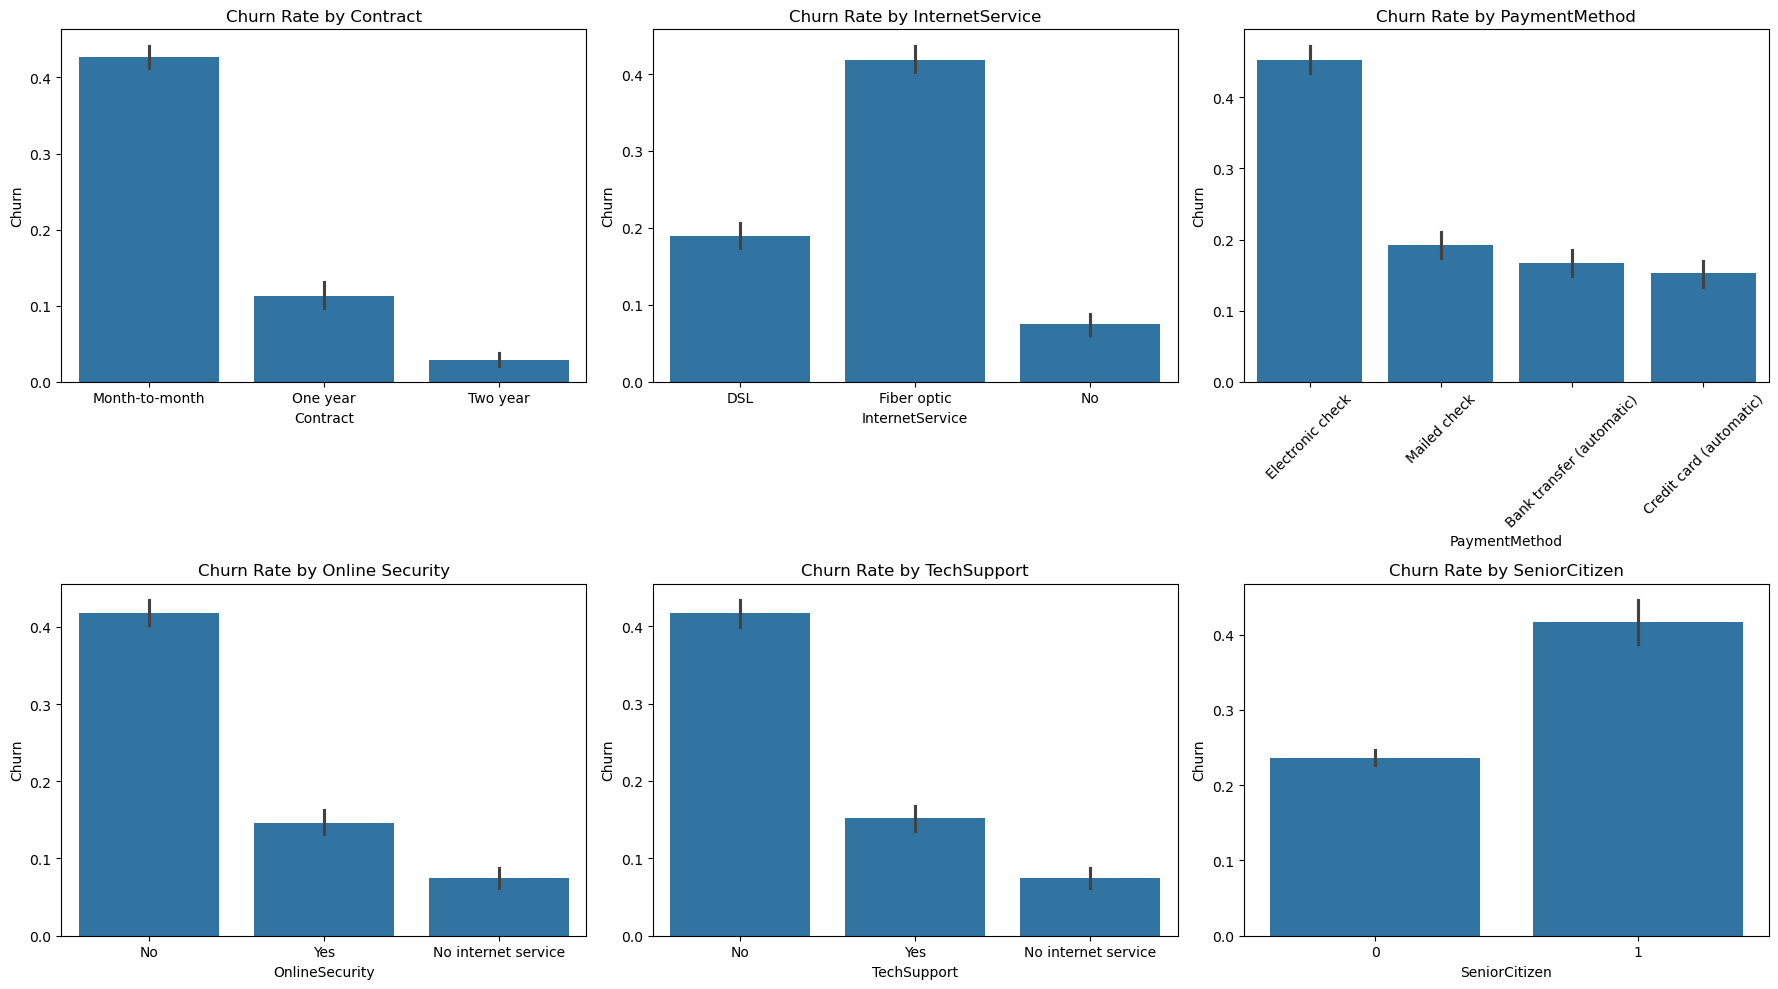

In [358]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.barplot(data=df, x="Contract", y="Churn", ax=axes[0, 0])
axes[0, 0].set_title('Churn Rate by Contract')

sns.barplot(data=df, x="InternetService", y="Churn", ax=axes[0, 1])
axes[0, 1].set_title('Churn Rate by InternetService')

sns.barplot(data=df, x="PaymentMethod", y="Churn", ax=axes[0, 2])
axes[0, 2].set_title('Churn Rate by PaymentMethod')
axes[0, 2].tick_params(axis="x", rotation=45) 

sns.barplot(data=df, x="OnlineSecurity", y="Churn", ax=axes[1, 0])
axes[1, 0].set_title('Churn Rate by Online Security')

sns.barplot(data=df, x="TechSupport", y="Churn", ax=axes[1, 1])
axes[1, 1].set_title('Churn Rate by TechSupport')

sns.barplot(data=df, x="SeniorCitizen", y="Churn", ax=axes[1, 2])
axes[1, 2].set_title('Churn Rate by SeniorCitizen')

plt.tight_layout()
plt.show()

Tenure and TotalCharges have 0.83 correlation. These two features display almost same information which can cause multicollinearity. Therefore, TotalCharges needs to be dropped.

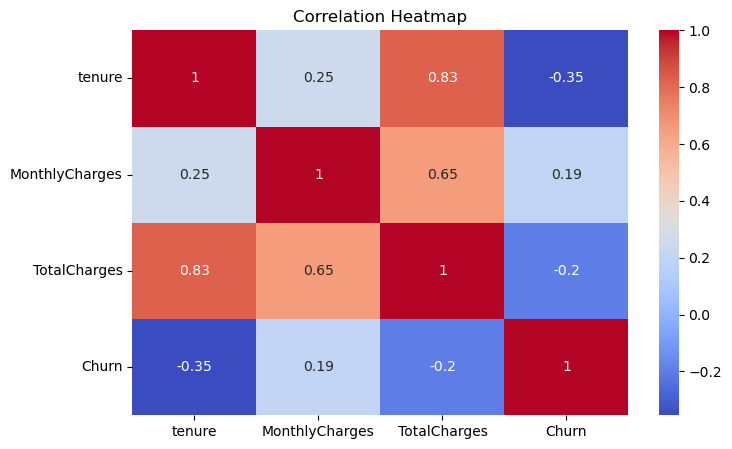

In [359]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr(), 
    annot=True, 
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering

In [360]:
df = df.drop(columns="TotalCharges")

Categorical values needs to be converted to numerical, and since there are multiple categories in some features, one-hot encoding is the best option.

In [361]:
df = pd.get_dummies(
    df, 
    columns=["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", 
             "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
             "TechSupport", "StreamingTV", "StreamingMovies", "Contract", 
             "PaperlessBilling", "PaymentMethod"], 
    drop_first=True, 
    dtype=int)

Num_services show how many services each customer have. Idealy, a customer with more services is commited and less likely to churn.

In [362]:
df['num_services'] = (
    df['PhoneService_Yes'] +
    df['OnlineSecurity_Yes'] +
    df['OnlineBackup_Yes'] +
    df['DeviceProtection_Yes'] +
    df['TechSupport_Yes'] +
    df['StreamingTV_Yes'] +
    df['StreamingMovies_Yes']
)

In [363]:
print(df.groupby('Churn')['num_services'].mean())

Churn
0    3.036994
1    2.677368
Name: num_services, dtype: float64


## Train/Test Split

In [364]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(5625, 30) (1407, 30)
0.2657777777777778 0.2658137882018479


## Class Imbalance

There is not a significant class imbalance and imbalance demonstrates real world scenario therefore addressing it with class_weights would be optimal approach here. Class_weights punishes minority class errors more harshly.

In [365]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
class_weight_dict = dict(enumerate(weights))

print(class_weight_dict)

{0: np.float64(0.6809994189424753), 1: np.float64(1.8812199036918138)}


## Scale

In [366]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Selection

In [367]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(class_weight=class_weight_dict, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight=class_weight_dict, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="roc_auc")
    print(f"{name}: mean={scores.mean():.3f}, std={scores.std():.3f}")

Logistic Regression: mean=0.844, std=0.020
Random Forest: mean=0.818, std=0.015
Gradient Boosting: mean=0.847, std=0.017


Logistic Regression and Gradient Boosting perform nearly identical (0.844 vs 0.847). This suggests that the relationship between features and churn is largely linear. However, Gradient Boosting is selected for its tuning potential and industry relevance.

## Tuning

In [368]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth":[3, 4, 5],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5, 
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_}")

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV ROC-AUC: 0.8474361673698446


GridSearch did not improve on ROC-AUC score at all. This suggests the model is already near its performance ceiling with this feature set. Further improvement would require better features rather than better hyperparameters.

In [379]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
train_score = best_model.score(X_train_scaled, y_train)
test_score = best_model.score(X_test_scaled, y_test)

print(f"Train: {train_score:.3f} | Test: {test_score:.3f} | Gap: {train_score-test_score:.3f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Train: 0.815 | Test: 0.795 | Gap: 0.020
[[931 102]
 [187 187]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.79      1407



In [377]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.3f}")

ROC-AUC Score: 0.842


The model is evaluated using ROC-AUC rather than accuracy because the dataset is imabalanced. Model that predicts no churn for every customer would have 73.4% accuracy. ROC-AUC (0.842) means the model correctly ranks a churner as more likely to churn than a non-churner 84.2% of the time.

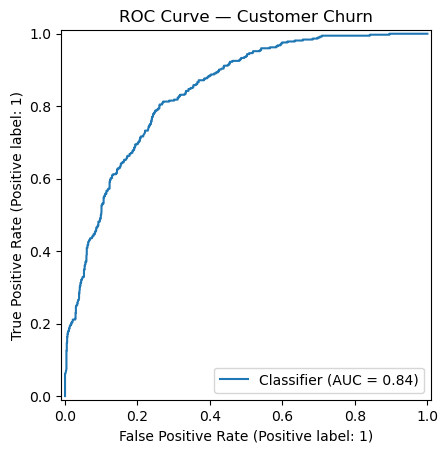

--- Threshold 0.3 ---
[[765 268]
 [ 77 297]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1033
           1       0.53      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.77      1407



In [378]:
# Threshold tuning
y_pred_adjusted = (y_pred_proba >= 0.3).astype(int)

RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title('ROC Curve — Customer Churn')
plt.show()

print("--- Threshold 0.3 ---")
print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted))

By default the model predicts churn when probability exceeds 0.5. 
Lowering this threshold to 0.3 makes the model more aggressive at 
flagging potential churners. The right threshold is ultimately a business decision, not a 
technical one. It depends on the cost of missing a churner versus 
the cost of offering retention deals to loyal customers who 
weren't going to leave anyway.

## Feature Importance

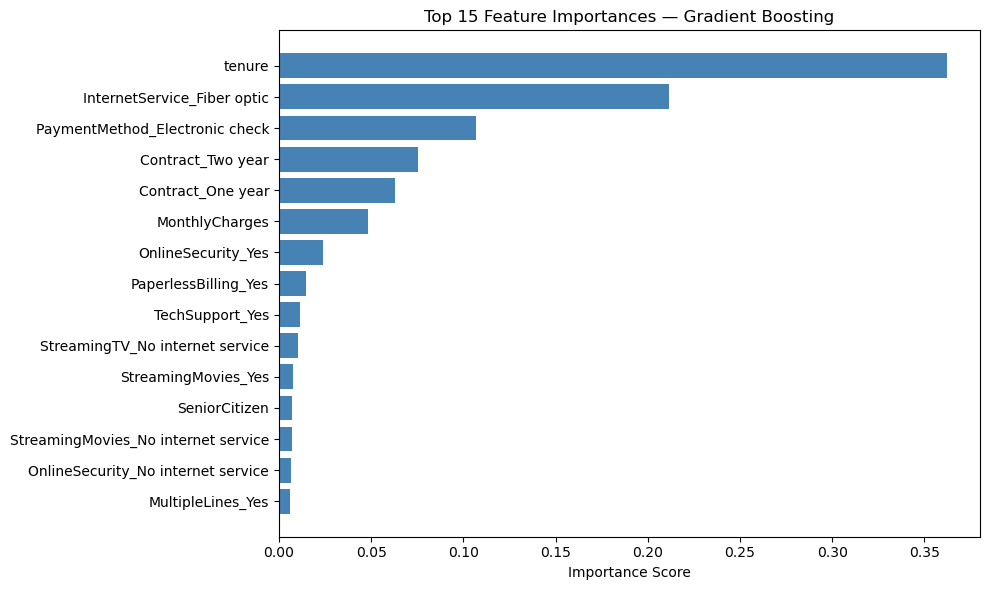

In [380]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
})
importance = importance.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('Top 15 Feature Importances — Gradient Boosting')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The graph results and EDA matches with each other. Tenure overall is the most important feature almost twice more important than second one. Fiber optic as internet service has also high importance score since it is expensive service and this price can drive customers to churn. It is also understood that out of 30 features, only a small proportion of these features have actual significance which also explains the model's limited performance.

## Saving the model

In [383]:
import joblib

joblib.dump(best_model, "customer_churn_model.joblib")
joblib.dump(scaler, "customer_churn_scaler.joblib")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
